In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("./data/dataset_phishing.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape       : {df.shape}")
print(f"Missing vals: {df.isnull().sum().sum()}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

# ── Target Distribution ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(df['status'].value_counts())
print(df['status'].value_counts(normalize=True).round(4))

# ── Encode target ──────────────────────────────────────────────────────────────
df['status_enc'] = (df['status'] == 'phishing').astype(int)

# ── Numerical Features ─────────────────────────────────────────────────────────
numerical_cols = [
    'length_url', 'length_hostname', 'nb_dots', 'nb_hyphens', 'nb_slash',
    'nb_subdomains', 'ratio_digits_url', 'ratio_digits_host',
    'length_words_raw', 'longest_words_raw', 'avg_words_raw',
    'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks',
    'page_rank', 'web_traffic', 'domain_age', 'domain_registration_length'
]

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS — NUMERICAL FEATURES")
print("=" * 60)
print(df[numerical_cols].describe().round(3).to_string())

print("\n" + "=" * 60)
print("SKEWNESS")
print("=" * 60)
print(df[numerical_cols].skew().round(3).sort_values(ascending=False).to_string())

# ── Zero-Variance Features ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ZERO-VARIANCE (CONSTANT) FEATURES")
print("=" * 60)
zero_var = []
for col in df.columns:
    if col not in ['url', 'status', 'status_enc']:
        if df[col].nunique() == 1:
            zero_var.append(col)
            print(f"  {col}: constant value = {df[col].unique()[0]}")
print(f"Total: {len(zero_var)} features")

# ── Missing Values per Column ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN (top 10)")
print("=" * 60)
print(df.isnull().sum().sort_values(ascending=False).head(10).to_string())

# ── Outlier Detection (IQR) ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("OUTLIER COUNTS (IQR METHOD)")
print("=" * 60)
outlier_cols = ['length_url', 'length_hostname', 'nb_dots', 'nb_hyphens',
                'nb_slash', 'nb_hyperlinks', 'longest_words_raw',
                'domain_registration_length', 'page_rank', 'domain_age']
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].shape[0]
    print(f"  {col:<35}: {n:>5} outliers ({n/len(df)*100:.1f}%)")

# ── Correlation with Target ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 10 CORRELATIONS WITH TARGET (|r|)")
print("=" * 60)
corr_target = (
    df[numerical_cols + ['status_enc']]
    .corr()['status_enc']
    .drop('status_enc')
    .abs()
    .sort_values(ascending=False)
)
print(corr_target.head(10).round(4).to_string())

# ── Binary Feature Class Proportions ──────────────────────────────────────────
print("\n" + "=" * 60)
print("BINARY FEATURE PROPORTIONS BY CLASS")
print("=" * 60)
binary_cols = [
    'ip', 'https_token', 'prefix_suffix', 'shortening_service', 'random_domain',
    'login_form', 'external_favicon', 'empty_title', 'domain_in_title',
    'domain_in_brand', 'whois_registered_domain', 'google_index'
]
print(f"{'Feature':<35} {'Legitimate':>12} {'Phishing':>12} {'Delta':>10}")
print("-" * 72)
for col in binary_cols:
    l = df[df['status'] == 'legitimate'][col].mean()
    p = df[df['status'] == 'phishing'][col].mean()
    print(f"  {col:<33} {l:>12.4f} {p:>12.4f} {p-l:>10.4f}")

DATASET OVERVIEW
Shape       : (11430, 89)
Missing vals: 0

Dtypes:
int64      74
float64    13
object      2
Name: count, dtype: int64

First 3 rows:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0                      1                        0   
1                1                      0                        0   
2                1                      0


Saved: fig1_target_dist.png


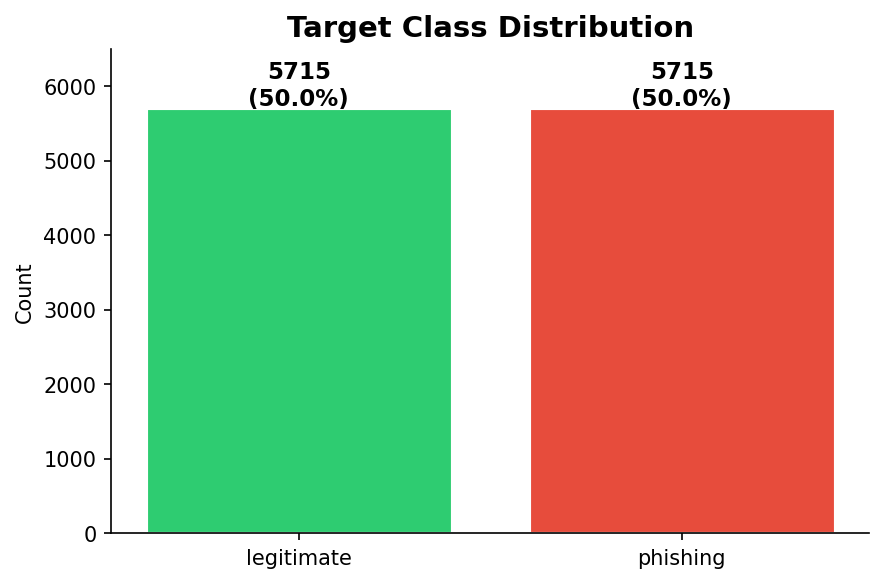

In [3]:
from IPython.display import Image, display
# ── Figure 1: Target Distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['status'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 6500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./Week2/fig1_target_dist.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: fig1_target_dist.png")
display(Image(filename='./Week2/fig1_target_dist.png'))

Saved: fig2_histograms.png


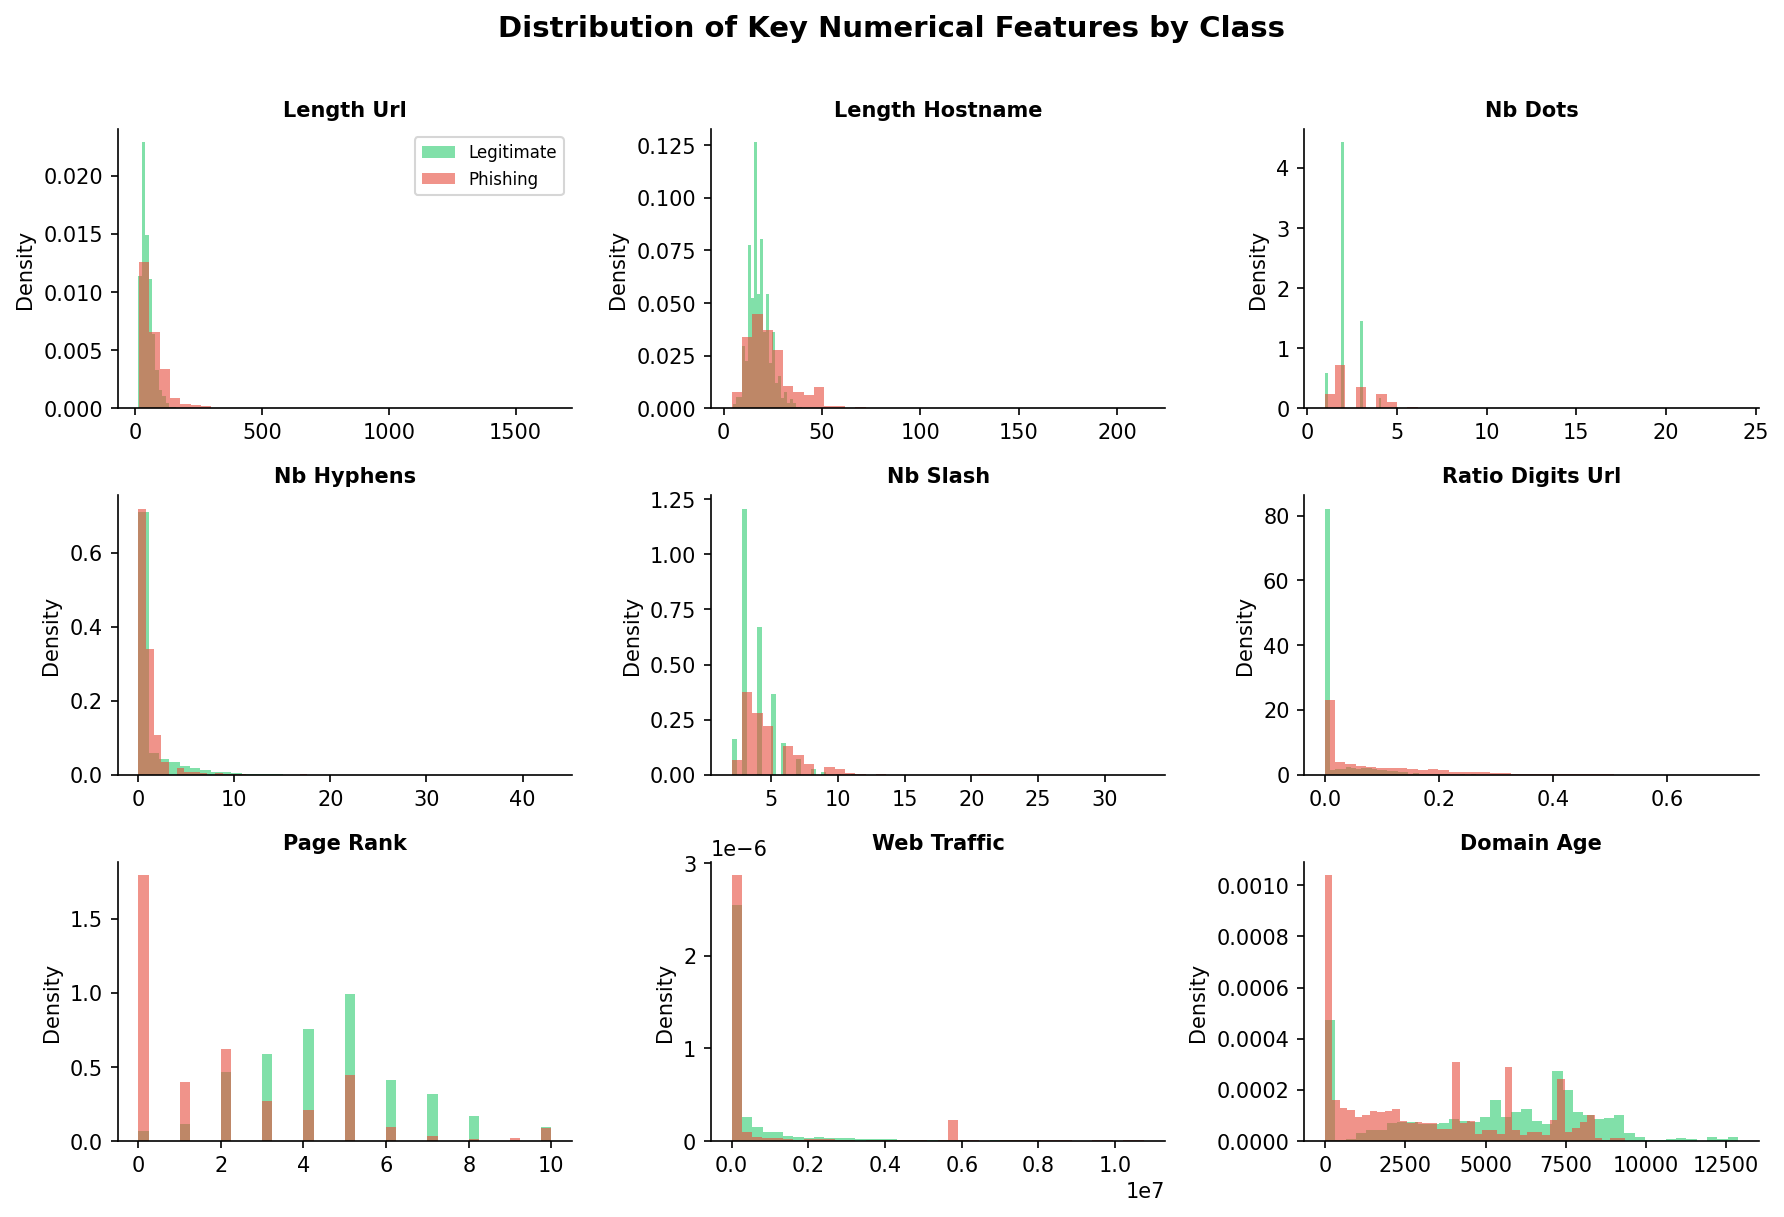

In [4]:
# ── Figure 2: Histograms ───────────────────────────────────────────────────────
key_num = ['length_url', 'length_hostname', 'nb_dots', 'nb_hyphens', 'nb_slash',
           'ratio_digits_url', 'page_rank', 'web_traffic', 'domain_age']
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(key_num):
    ax = axes[i]
    ax.hist(df[df['status'] == 'legitimate'][col], bins=40, alpha=0.6,
            color='#2ecc71', label='Legitimate', density=True)
    ax.hist(df[df['status'] == 'phishing'][col], bins=40, alpha=0.6,
            color='#e74c3c', label='Phishing', density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle('Distribution of Key Numerical Features by Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./Week2/fig2_histograms.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig2_histograms.png")
display(Image(filename='./Week2/fig2_histograms.png'))

Saved: fig3_heatmap.png


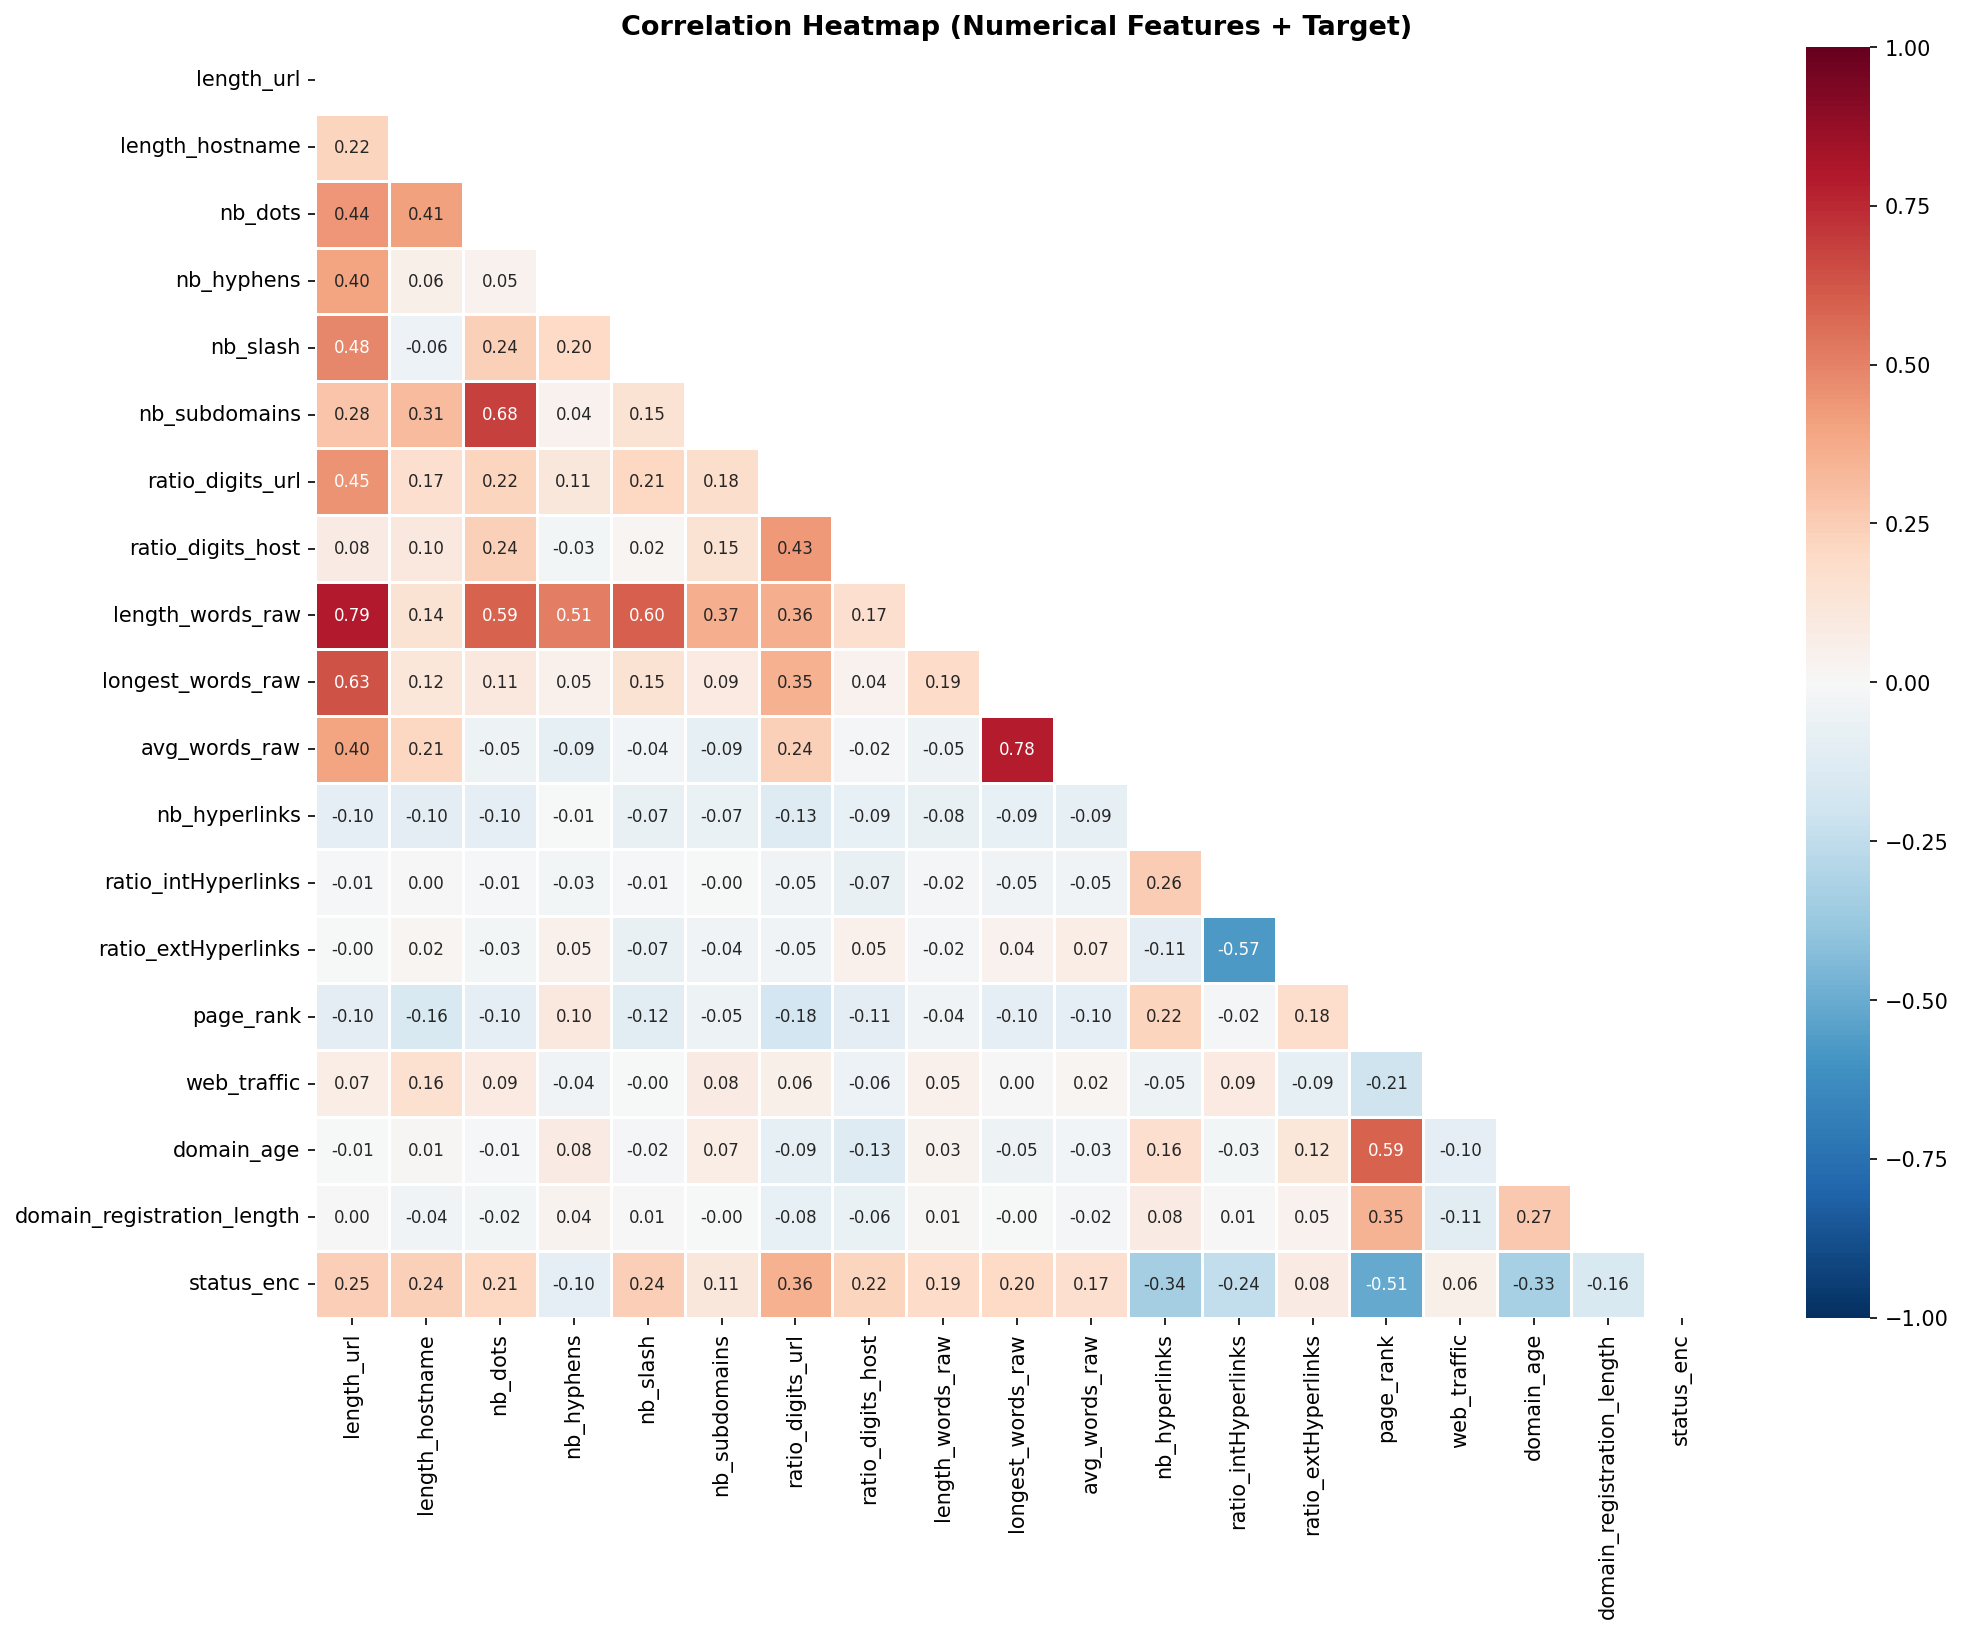

In [5]:
# ── Figure 3: Correlation Heatmap ─────────────────────────────────────────────
corr = df[numerical_cols + ['status_enc']].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 8}, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Numerical Features + Target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week2/fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig3_heatmap.png")
display(Image(filename='./Week2/fig3_heatmap.png'))

Saved: fig4_boxplots.png


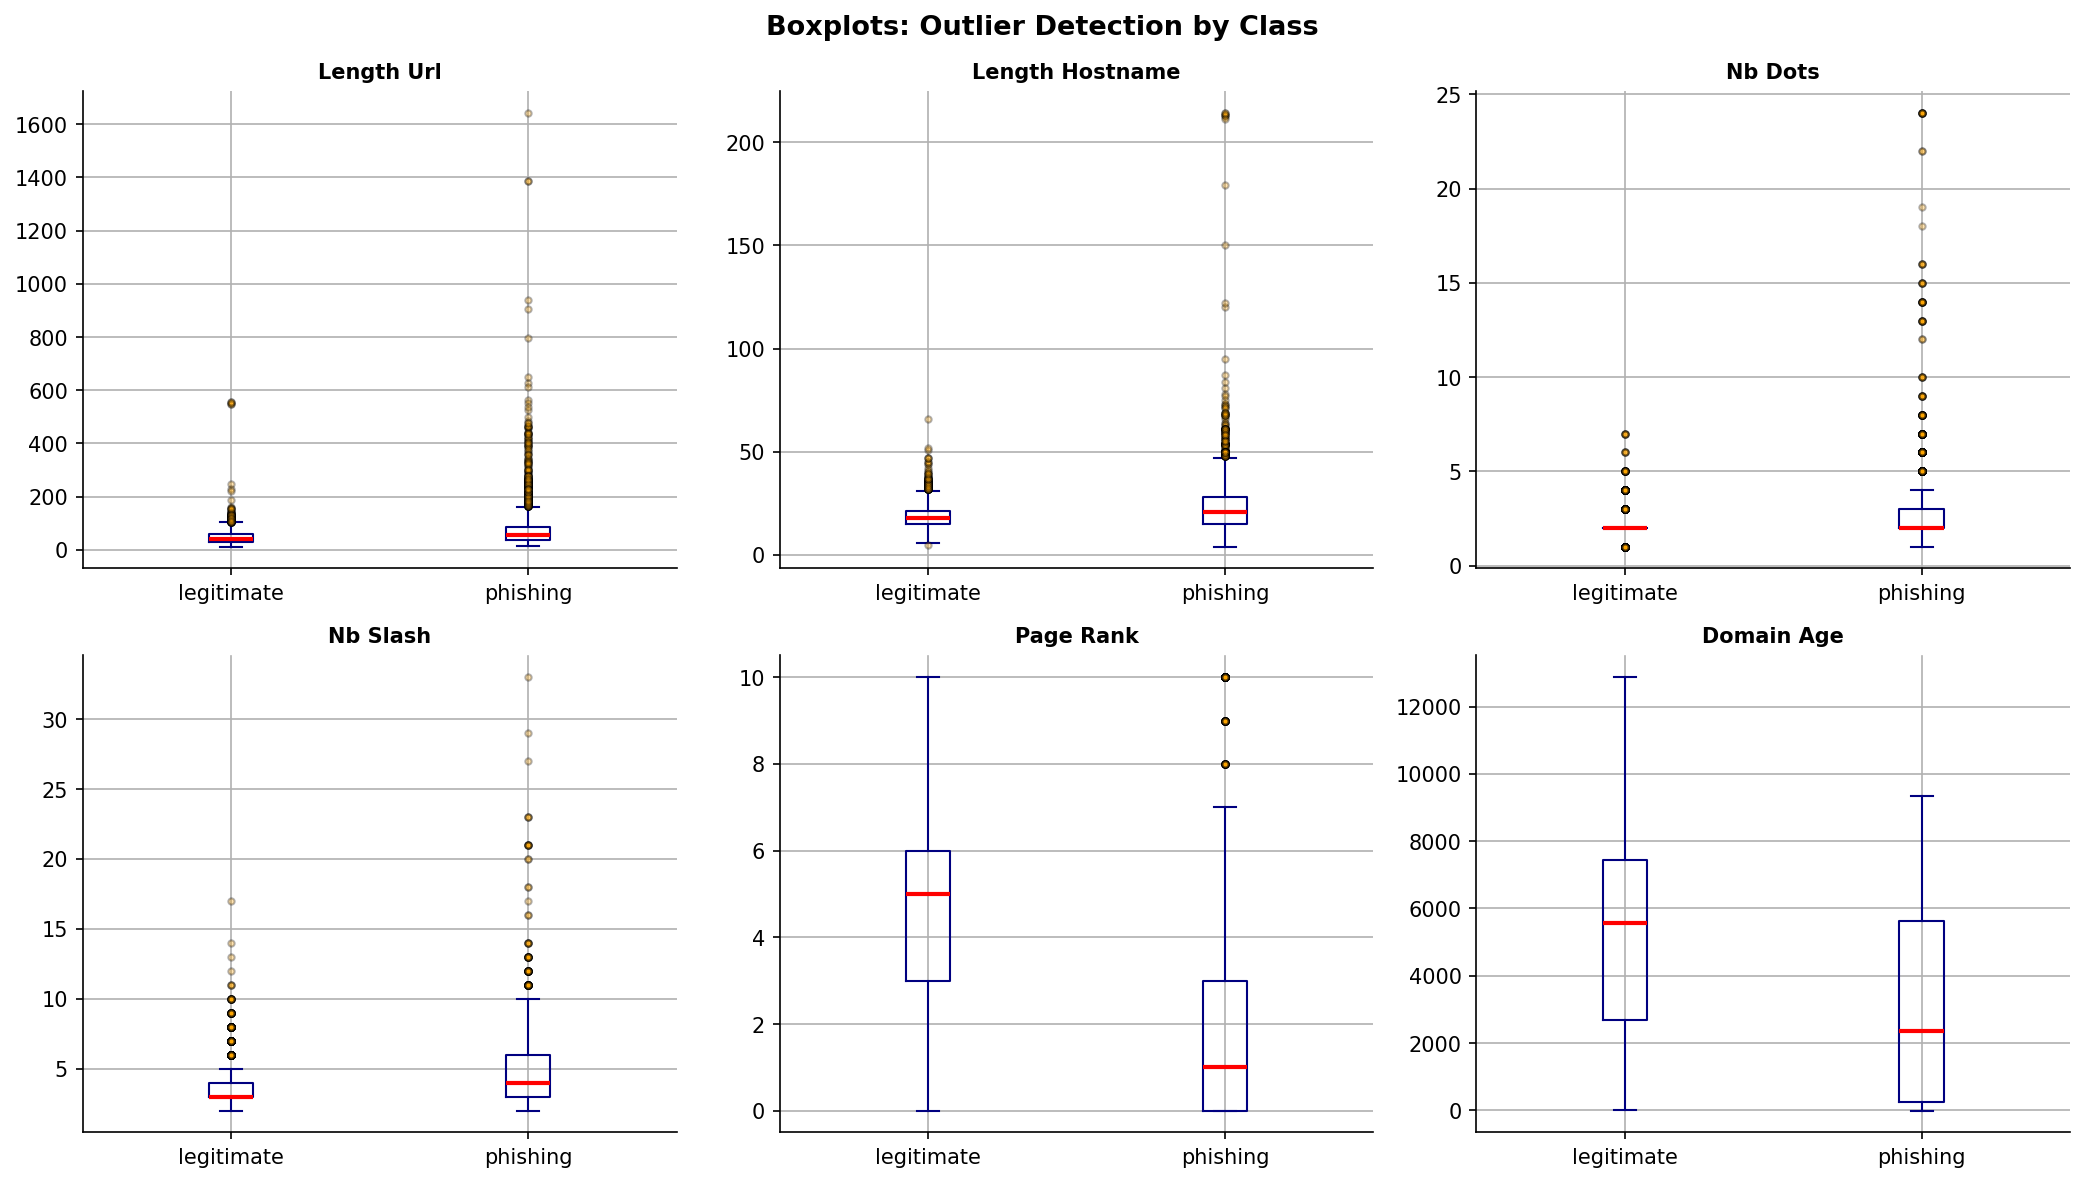

In [6]:
# ── Figure 4: Boxplots ─────────────────────────────────────────────────────────
box_cols = ['length_url', 'length_hostname', 'nb_dots',
            'nb_slash', 'page_rank', 'domain_age']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(box_cols):
    ax = axes[i]
    df.boxplot(column=col, by='status', ax=ax,
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               capprops=dict(color='navy'),
               flierprops=dict(marker='o', markerfacecolor='orange',
                               markersize=3, alpha=0.3))
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Boxplots: Outlier Detection by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week2/fig4_boxplots.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig4_boxplots.png")
display(Image(filename='./Week2/fig4_boxplots.png'))

Saved: fig5_binary_features.png


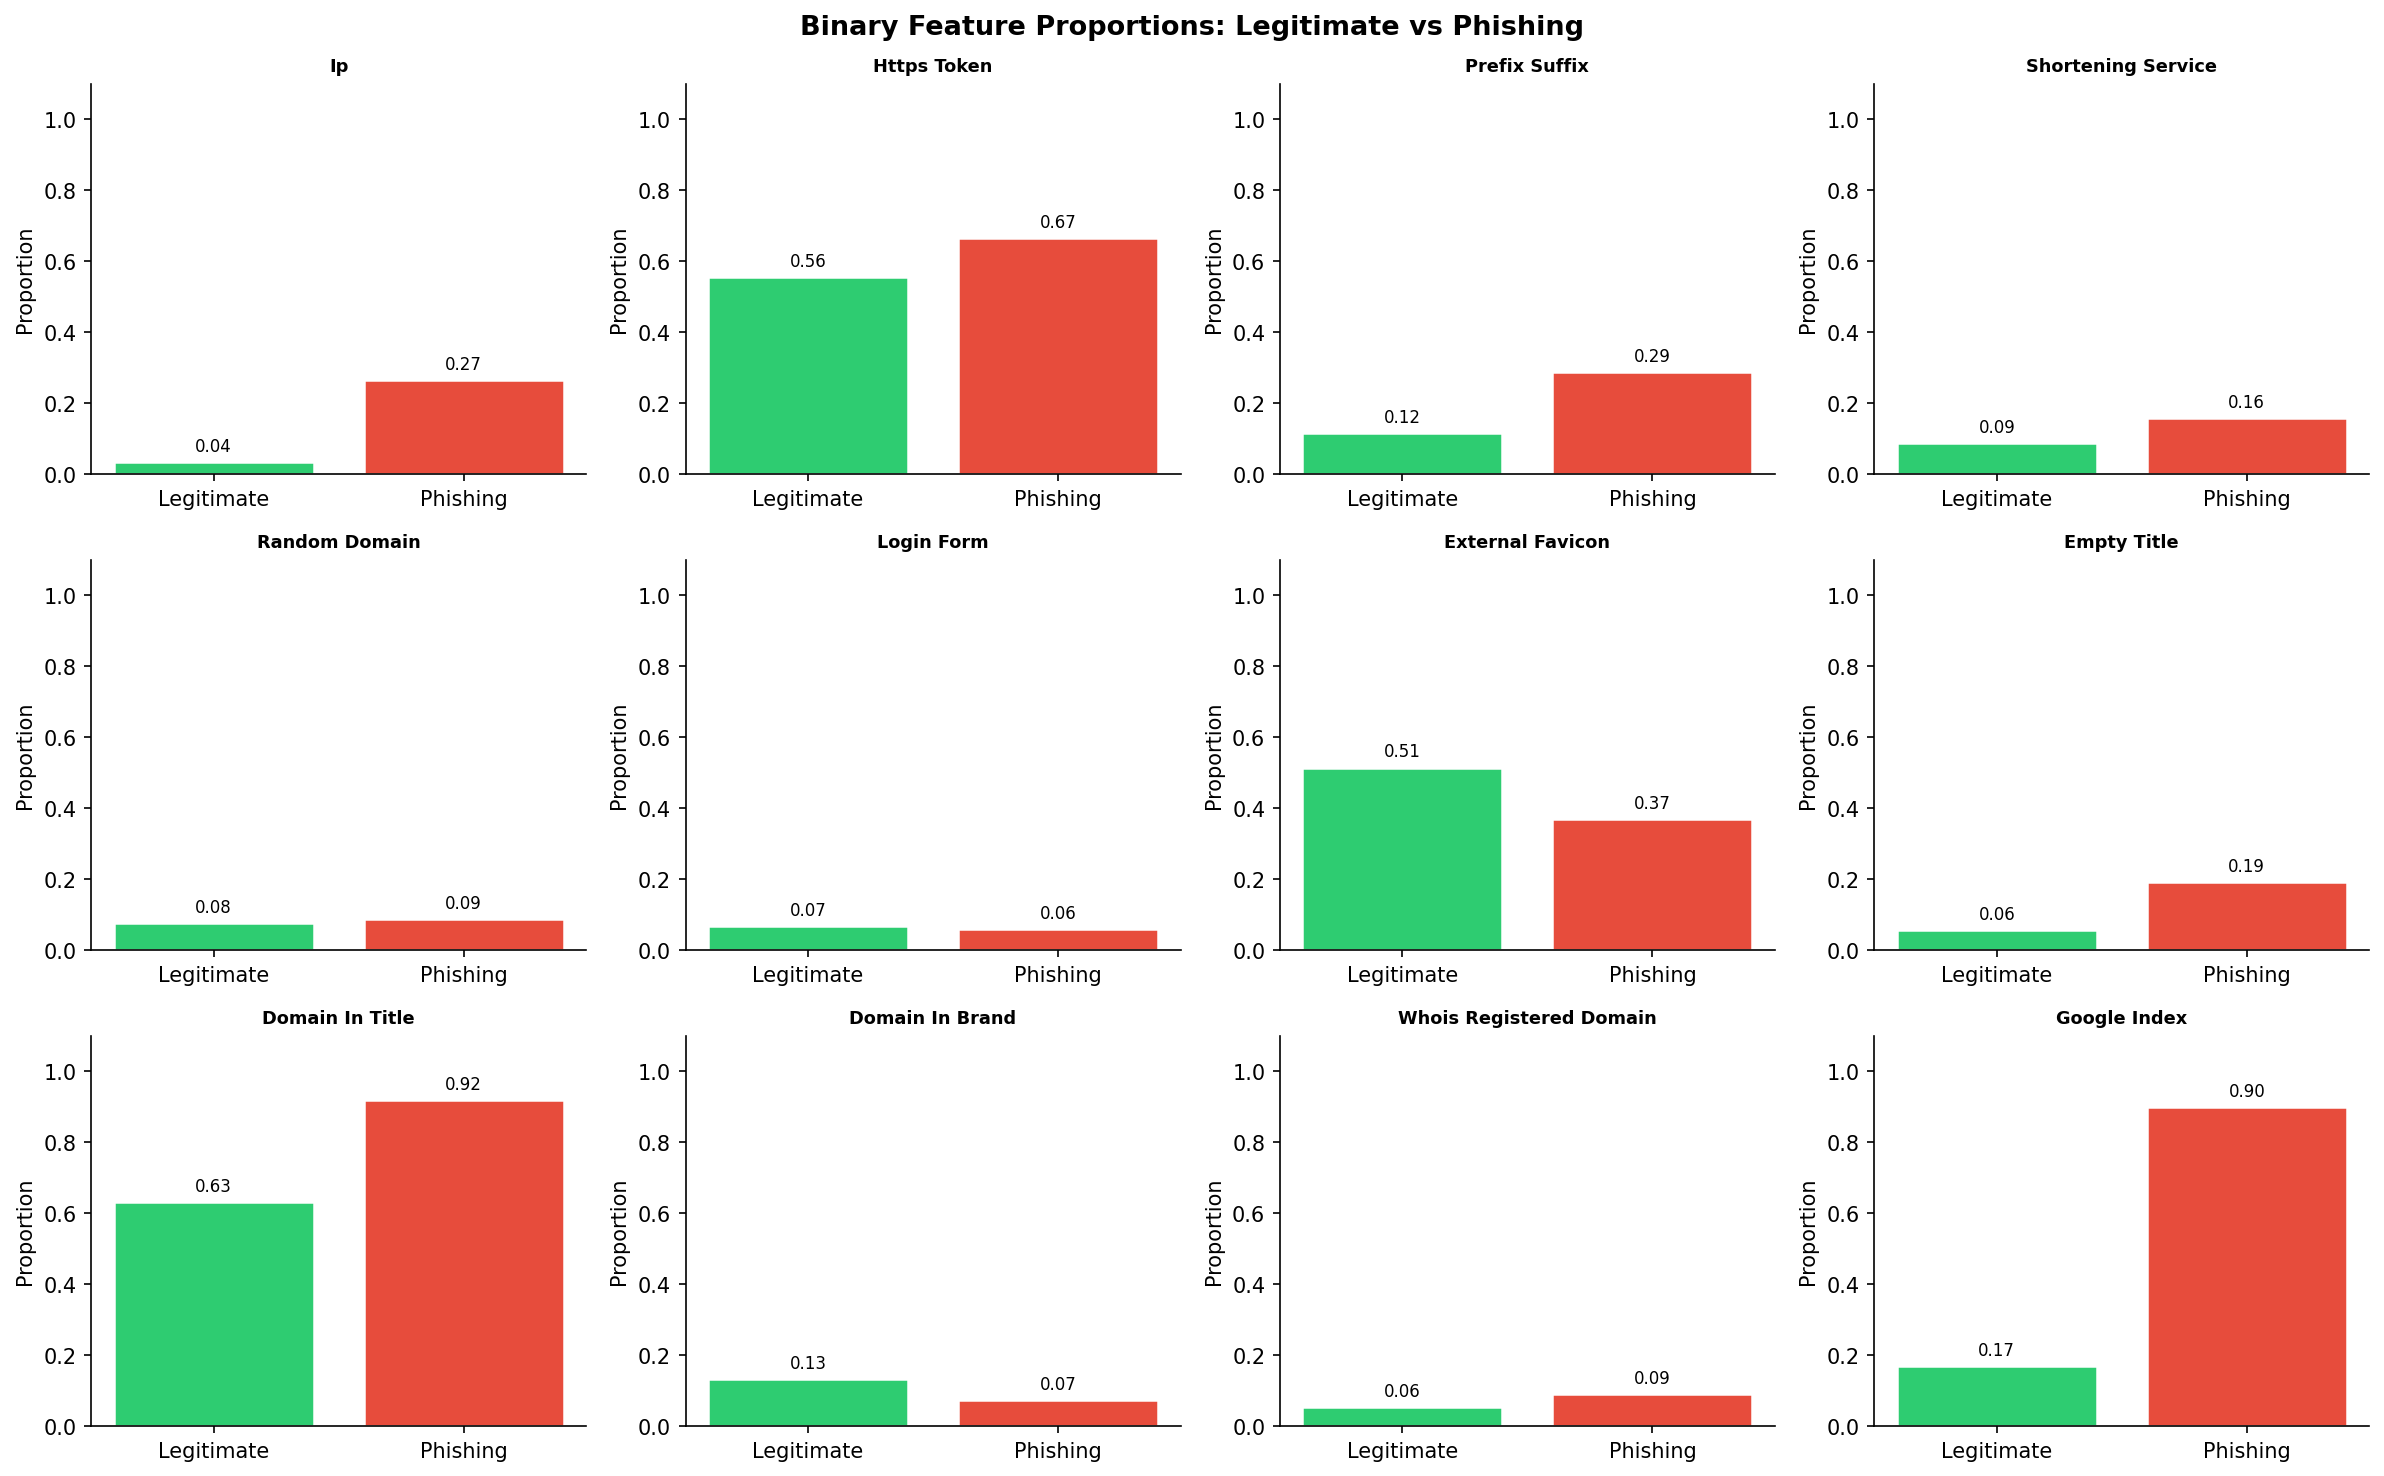

In [7]:
# ── Figure 5: Binary Feature Comparison ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    ax = axes[i]
    l = df[df['status'] == 'legitimate'][col].mean()
    p = df[df['status'] == 'phishing'][col].mean()
    ax.bar(['Legitimate', 'Phishing'], [l, p],
           color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2)
    ax.set_title(col.replace('_', ' ').title(), fontsize=8.5, fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for j, v in enumerate([l, p]):
        ax.text(j, v + 0.03, f'{v:.2f}', ha='center', fontsize=8)
fig.suptitle('Binary Feature Proportions: Legitimate vs Phishing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week2/fig5_binary_features.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig5_binary_features.png")
display(Image(filename='./Week2/fig5_binary_features.png'))

Saved: fig6_pairplot.png

All outputs generated successfully.


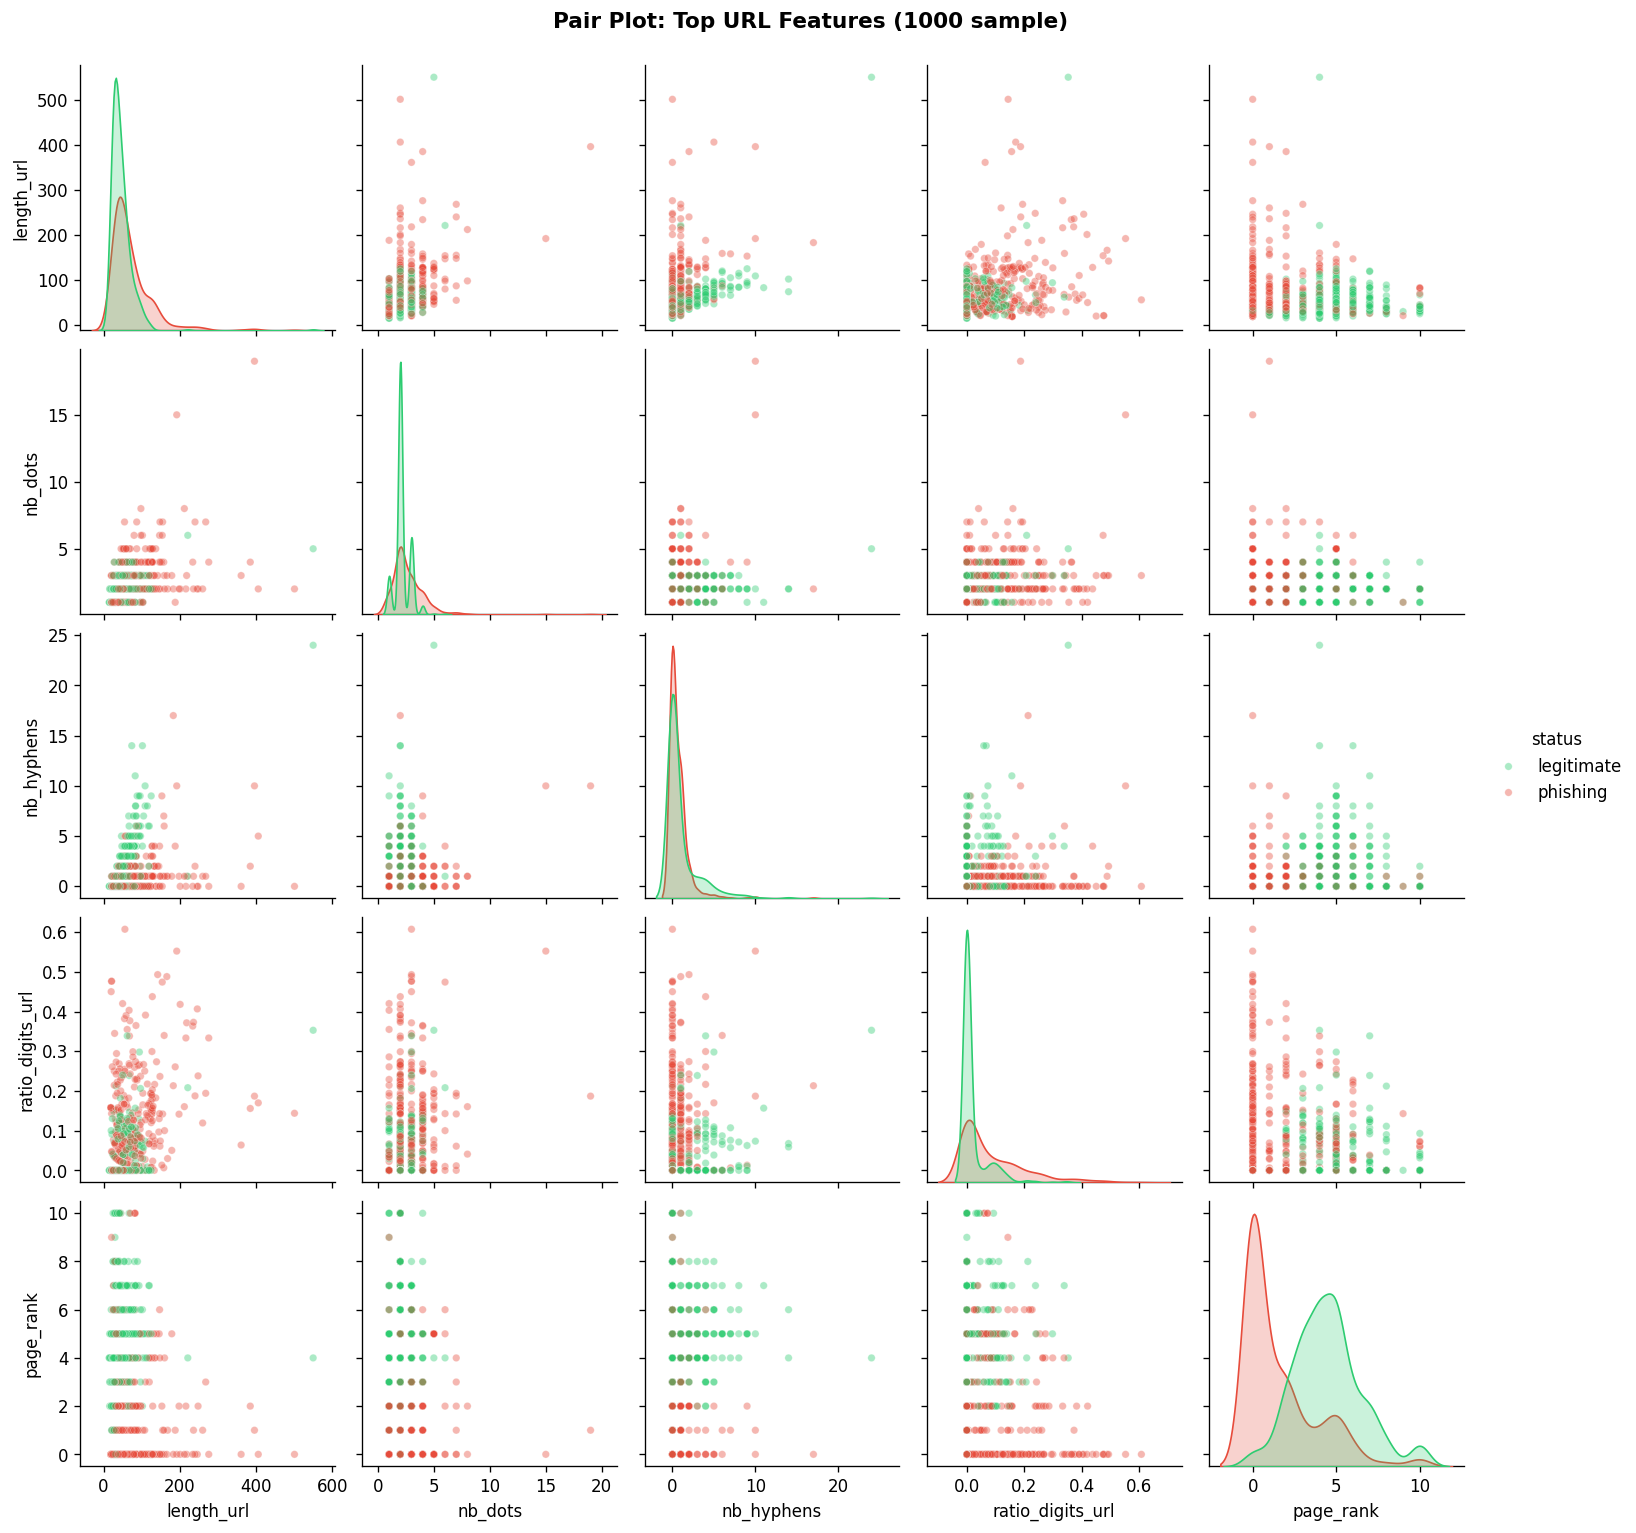

In [8]:
# ── Figure 6: Pair Plot ────────────────────────────────────────────────────────
top_features = ['length_url', 'nb_dots', 'nb_hyphens',
                'ratio_digits_url', 'page_rank', 'status']
pairdf = df[top_features].sample(1000, random_state=42)
g = sns.pairplot(pairdf, hue='status',
                 palette={'legitimate': '#2ecc71', 'phishing': '#e74c3c'},
                 plot_kws={'alpha': 0.4, 's': 20}, diag_kind='kde')
g.fig.suptitle('Pair Plot: Top URL Features (1000 sample)',
               y=1.02, fontsize=13, fontweight='bold')
plt.savefig('./Week2/fig6_pairplot.png', dpi=120, bbox_inches='tight')
plt.close()
print("Saved: fig6_pairplot.png")

print("\nAll outputs generated successfully.")
display(Image(filename='./Week2/fig6_pairplot.png'))